In [10]:
import pandas as pd

df= pd.read_csv("Book1.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Choose Features

In [11]:
x = df[['Annual Income (k$)', 'Spending Score (1-100)']]

KMeans Clustering - Model grouped customers into 5 types

In [12]:
from sklearn.cluster import KMeans

KMeans = KMeans(n_clusters=5)

KMeans.fit(x)

df['Cluster'] = KMeans.labels_

Visualize

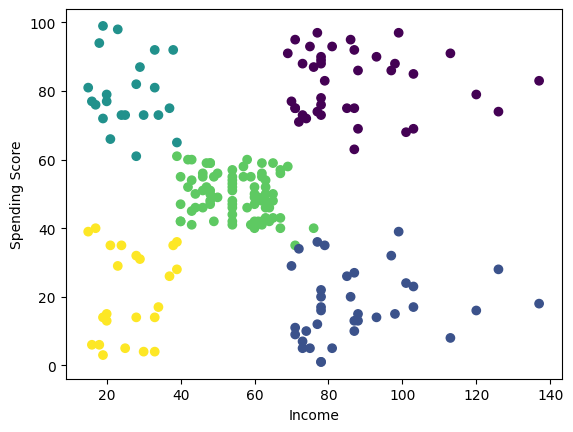

In [13]:
import matplotlib.pyplot as plt

plt.scatter(x['Annual Income (k$)'], x['Spending Score (1-100)'] , c=df['Cluster'])
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.show()

👉 You used n_clusters=5 randomly
👉 That’s not professional

Find BEST number of clusters (Elbow Method)
Choose correct number of clusters (not guessing)
🧠 Idea

We test:
👉 1 cluster, 2 clusters, 3… up to 10

And measure:
👉 Inertia (error)


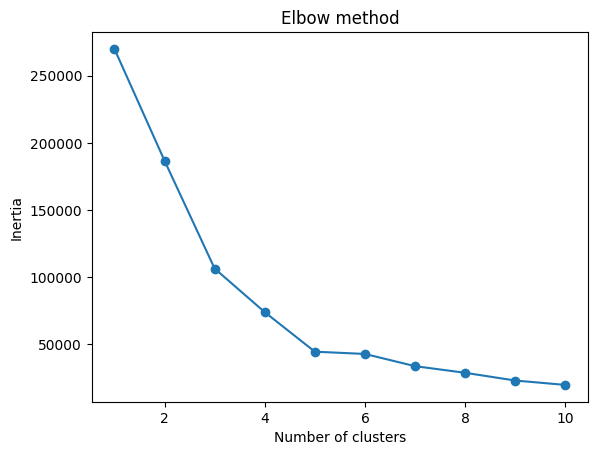

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):
    Kmeans = KMeans(n_clusters=k)
    Kmeans.fit(x)
    inertia.append(Kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()

👉 The “bend” (elbow point) = best cluster number

Apply best K

In [15]:
Kmeans= KMeans(n_clusters=5)
df["Cluster"] = Kmeans.fit_predict(x)

🔥 Upgrade Visualization

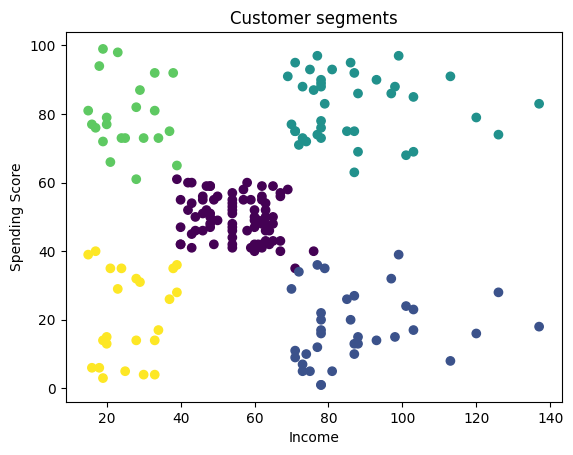

In [16]:
plt.scatter(x["Annual Income (k$)"], x['Spending Score (1-100)'], c=df["Cluster"])

plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.title('Customer segments')
plt.show()

Analyze Each Cluster

In [17]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         85.737500  42.937500           55.087500               49.712500
1        163.500000  40.666667           87.750000               17.583333
2        162.000000  32.692308           86.538462               82.128205
3         23.090909  25.272727           25.727273               79.363636
4         23.000000  45.217391           26.304348               20.913043


Add Labels to Data

In [18]:
def label_customer(cluster):
    if cluster == 2:
        return "VIP"
    elif cluster == 1:
        return "Potential"
    elif cluster == 0:
        return "Average"
    elif cluster == 3:
        return "Low Value"
    elif cluster == 4:
        return "Young Spenders"


In [19]:
df['Segment'] = df['Cluster'].apply(label_customer)

Count customers in each segment

In [20]:
print(df['Segment'].value_counts())

Segment
Average           80
VIP               39
Potential         36
Young Spenders    23
Low Value         22
Name: count, dtype: int64


💰 Business insights (IMPORTANT)

You can now say:

Focus marketing on Potential customers

Retain VIP customers with loyalty offers

Ignore or minimize effort on Low Value customers

Target Young Spenders with trendy products